In [2]:
from google.colab import files
uploaded = files.upload()

Saving NJPubSchool.csv to NJPubSchool.csv
Saving enrollment_2425.xlsx to enrollment_2425.xlsx
Saving newjerseypdf-40553.pdf to newjerseypdf-40553.pdf


In [37]:
import pandas as pd

# Load directory file
directory = pd.read_csv("NJPubSchool.csv", skiprows=3, encoding='latin1')

# List of columns to clean
columns_to_clean = ['County Code', 'District Code', 'School Code', 'NCES Code']

# Clean columns
for col in columns_to_clean:
    if col in directory.columns:
        directory[col] = directory[col].astype(str).str.replace(r'="|"', '', regex=True)

display(directory.head())

,County Code,County Name,District Code,District Name,School Code,School Name,Princ. Title,Princ. First Name,Princ. Last Name,Princ. Title 2,...,Grade 6,Grade 7,Grade 8,Grade 9,Grade 10,Grade 11,Grade 12,Post Grad,Adult Ed.,NCES Code
0,01,ATLANTIC,0010,Absecon Public Schools District,050,Emma C Attales,Mr.,Kevin,Burns,School Principal,...,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,00004
1,01,ATLANTIC,0010,Absecon Public Schools District,060,H Ashton Marsh,Ms.,Leslie,Schiavo,School Principal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00006
2,01,ATLANTIC,0110,Atlantic City School District,010,Atlantic City High School,Mrs.,Constance,Days -Chapman,School Principal,...,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN,00010
3,01,ATLANTIC,0110,Atlantic City School District,300,Brighton Avenue School,Mr.,Jason,Grimes,School Principal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
4,01,ATLANTIC,0110,Atlantic City School District,050,Chelsea Heights School,Mr.,James,Knox,School Principal,...,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,00016


In [4]:
# Load enrollment file and identify relevant columns
enrollment = pd.read_excel(
    "enrollment_2425.xlsx",
    sheet_name="School",
    skiprows=2
)

print(enrollment.columns)
display(enrollment.loc[:,['Fifth Grade', '%Fifth Grade', 'Sixth Grade', '%Sixth Grade', 'Seventh Grade', '%Seventh Grade', 'Eighth Grade', '%Eighth Grade']].head())

Index(['County Code', 'County Name', 'District Code', 'District Name',
       'School Code', 'School Name', 'Total Enrollment', 'White', '%White',
       'Black', '%Black', 'Hispanic', '%Hispanic', 'Asian', '%Asian',
       'Native American', '%Native American', 'Hawaiian Native',
       '%Hawaiian Native', 'Two or More Races', '%Two or More Races',
       'Pre-K Halfday', '%Pre-K Halfday', 'Pre-K FullDay', '%Pre-K FullDay',
       'Kindergarten Halfday', '%Kindergarten Halfday', 'Kindergarten Fullday',
       '%Kindergarten Fullday', 'First Grade', '%First Grade', 'Second Grade',
       '%Second Grade', 'Third Grade', '%Third Grade', 'Fourth Grade',
       '%Fourth Grade', 'Fifth Grade', '%Fifth Grade', 'Sixth Grade',
       '%Sixth Grade', 'Seventh Grade', '%Seventh Grade', 'Eighth Grade',
       '%Eighth Grade', 'Ninth Grade', '%Ninth Grade', 'Tenth Grade',
       '%Tenth Grade', 'Eleventh Grade', '%Eleventh Grade', 'Twelfth Grade',
       '%Twelfth Grade', 'Free Lunch', '%Free Lunc

,Fifth Grade,%Fifth Grade,Sixth Grade,%Sixth Grade,Seventh Grade,%Seventh Grade,Eighth Grade,%Eighth Grade
0,88.0,22.4,84.0,21.4,116.0,29.6,104.0,26.5
1,2.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,34.0,11.3,0.0,0.0,0.0,0.0,0.0,0.0
4,32.0,12.0,33.0,12.4,40.0,15.0,30.0,11.2


In [5]:
# Create new field of total students grade 5-8
enrollment["grade_5_8_total"] = (
    enrollment["Fifth Grade"] +
    enrollment["Sixth Grade"] +
    enrollment["Seventh Grade"] +
    enrollment["Eighth Grade"]
)

display(enrollment[[
    "School Name",
    "District Name",
    "grade_5_8_total"
]].head())

,School Name,District Name,grade_5_8_total
0,Emma C Attales,Absecon Public Schools District,392.0
1,H Ashton Marsh,Absecon Public Schools District,2.0
2,Atlantic City High School,Atlantic City School District,0.0
3,Brighton Avenue School,Atlantic City School District,34.0
4,Chelsea Heights School,Atlantic City School District,135.0


In [6]:
# Clean school and district names for matching
def clean_name(x):
    if pd.isna(x):
        return x
    return str(x).upper().strip()

enrollment["school_clean"] = enrollment["School Name"].apply(clean_name)
enrollment["district_clean"] = enrollment["District Name"].apply(clean_name)

directory["school_clean"] = directory["School Name"].apply(clean_name)
directory["district_clean"] = directory["District Name"].apply(clean_name)

In [7]:
# Merge enrollment and directory files based on school and district
merged = enrollment.merge(
    directory,
    on=["school_clean", "district_clean"],
    how="left",
    suffixes=("_enroll", "_dir")
)

display(merged[[
    "School Name_enroll",
    "District Name_enroll",
    "County Name_dir",
    "grade_5_8_total"
]].head())

,School Name_enroll,District Name_enroll,County Name_dir,grade_5_8_total
0,Emma C Attales,Absecon Public Schools District,ATLANTIC,392.0
1,H Ashton Marsh,Absecon Public Schools District,ATLANTIC,2.0
2,Atlantic City High School,Atlantic City School District,ATLANTIC,0.0
3,Brighton Avenue School,Atlantic City School District,ATLANTIC,34.0
4,Chelsea Heights School,Atlantic City School District,ATLANTIC,135.0


In [12]:
import pdfplumber

rows = []

# Load Title I pdf file
with pdfplumber.open("newjerseypdf-40553.pdf") as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        lines = text.split("\n")
        for line in lines:
            rows.append(line)

title1_raw = pd.DataFrame(rows, columns=["raw_text"])
title1_raw.head(20)

,raw_text
0,Title I Grants to Local Educational Agencies -...
1,Allocations under the American Recovery and Re...
2,Title I Allocations
3,LEA ID District Under the Recovery Act*
4,"3400660 ABSECON CITY 90,622"
5,3400690 ALEXANDRIA TOWNSHIP 0
6,3400720 ALLAMUCHY TOWNSHIP 0
7,3400750 ALLENDALE BOROUGH 0
8,3400780 ALLENHURST 0
9,"3400810 ALLOWAY TOWNSHIP 42,697"


In [13]:
import re

filtered_rows = []

# Keep only rows with Title I data
for line in rows:
    if re.match(r"^\d+", line):
        filtered_rows.append(line)

filtered_rows[:10]

['3400660 ABSECON CITY 90,622',
 '3400690 ALEXANDRIA TOWNSHIP 0',
 '3400720 ALLAMUCHY TOWNSHIP 0',
 '3400750 ALLENDALE BOROUGH 0',
 '3400780 ALLENHURST 0',
 '3400810 ALLOWAY TOWNSHIP 42,697',
 '3400840 ALPHA BOROUGH 44,440',
 '3400870 ALPINE BOROUGH 23,527',
 '3400900 ANDOVER REG 0',
 '3400930 ASBURY PARK CITY 1,022,940']

In [14]:
clean_rows = []

# Convert into data frame with original file format
for line in filtered_rows:
    match = re.match(r"(\d+)\s+(.+?)\s+([\d,]+)$", line)
    if match:
        lea_id = match.group(1)
        district = match.group(2).strip()
        amount = int(match.group(3).replace(",", ""))

        clean_rows.append([lea_id, district, amount])

import pandas as pd

title1 = pd.DataFrame(clean_rows, columns=[
    "lea_id", "district_name", "allocation"
])

title1.head()

,lea_id,district_name,allocation
0,3400660,ABSECON CITY,90622
1,3400690,ALEXANDRIA TOWNSHIP,0
2,3400720,ALLAMUCHY TOWNSHIP,0
3,3400750,ALLENDALE BOROUGH,0
4,3400780,ALLENHURST,0


In [15]:
# Define flag for Title I districts
title1["is_title1"] = title1["allocation"] > 0

In [16]:
# Clean district names in Title I data frame
def clean_name(x):
    if pd.isna(x):
        return x
    return (
        str(x)
        .upper()
        .strip()
        .replace(".", "")
        .replace(",", "")
    )

title1["district_clean"] = title1["district_name"].apply(clean_name)

In [17]:
import re

# Function to remove key words from district names to match pdf file
def clean_district_advanced(x):
    if pd.isna(x):
        return x

    x = str(x).upper().strip()

    # Remove punctuation
    x = re.sub(r"[.,]", "", x)

    # Remove common words
    remove_words = [
        "SCHOOL",
        "PUBLIC",
        "SPECIAL",
        "SERVICES",
        "VOCATIONAL",
        "COMMUNITY",
        "PREP",
        "TWP",
        "CONSOLIDATED",
        "ELEMENTARY",
        "VILLAGE",
        "REGIONAL",
        "DISTRICT",
        "INSTITUTE",
        "EDUCATIONAL",
        "OF",
        "K-8",
        "BORO",
        "TECHNOLOGY",
        "TECHNICAL",
        "ACADEMY",
        "COLLEGE",
        "EXCELLENCE",
        "HIGH"
    ]

    for word in remove_words:
        x = x.replace(word, "")

    x = re.sub(r"\s+", " ", x).strip()

    return x

In [18]:
# Create district key field in merged data frame by cleaning names
merged["district_key"] = merged["District Name_enroll"].apply(clean_district_advanced)

In [19]:
# Identify Title I districts, then flag in merged df, looking for partial matches
title1_true = title1[title1["is_title1"] == True]
title1_list = title1_true["district_clean"].unique().tolist()

def is_title1_match(district):
    if pd.isna(district):
        return False

    for t in title1_list:
        if t in district or district in t:
            return True
    return False

merged["is_title1"] = merged["district_key"].apply(is_title1_match)
merged["is_title1"].value_counts()

,count
is_title1,
True,1318
False,1192


In [20]:
# Create df of only Title I schools
title1_only = merged[merged["is_title1"] == True]

In [21]:
# Create ranking of counties by students in grade 5-8 from Title I schools
county_rank = (
    title1_only.groupby("County Name_dir")["grade_5_8_total"]
    .sum()
    .reset_index()
    .sort_values(by="grade_5_8_total", ascending=False)
)

county_rank.head(10)

,County Name_dir,grade_5_8_total
8,HUDSON,21496.0
6,ESSEX,21124.0
3,CAMDEN,18500.0
15,PASSAIC,17177.0
11,MIDDLESEX,16363.0
1,BERGEN,16295.0
14,OCEAN,15150.0
10,MERCER,12397.0
0,ATLANTIC,10848.0
7,GLOUCESTER,8487.0


In [40]:
# Create ranking of schools by students in grade 5-8 within each Title I district
school_rank = (
    title1_only.groupby(
        ["district_key", "School Name_enroll"]
    )["grade_5_8_total"]
    .sum()
    .reset_index()
)

school_rank["rank"] = school_rank.groupby(
    "district_key"
)["grade_5_8_total"].rank(ascending=False, method="dense")

school_rank.sort_values(["district_key", "rank"]).head(20)

,district_key,School Name_enroll,grade_5_8_total,rank
0,ALLOWAY,Alloway Township School,124.0,1.0
1,ALPINE,Alpine Elementary School,72.0,1.0
4,ASBURY PARK,"Dr. Martin Luther King, Jr. Middle School",195.0,1.0
3,ASBURY PARK,Bradley Elementary School,170.0,2.0
2,ASBURY PARK,Asbury Park High School,0.0,3.0
5,ASBURY PARK,Thurgood Marshall Elementary School,0.0,3.0
13,ATLANTIC CITY,Sovereign Avenue School,298.0,1.0
12,ATLANTIC CITY,Richmond Avenue School,279.0,2.0
14,ATLANTIC CITY,Texas Avenue School,252.0,3.0
10,ATLANTIC CITY,New York Avenue School,228.0,4.0


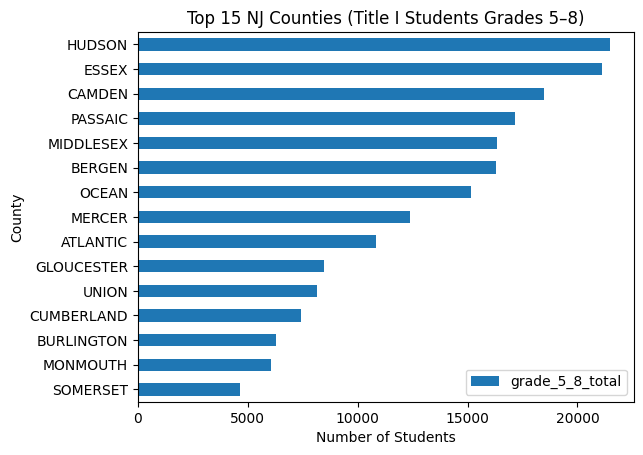

In [38]:
import matplotlib.pyplot as plt

# Create bar chart for top 15 counties based on rankings
county_rank.head(15).plot(
    kind="barh",
    x="County Name_dir",
    y="grade_5_8_total"
)

plt.title("Top 15 NJ Counties (Title I Students Grades 5–8)")
plt.xlabel("Number of Students")
plt.ylabel("County")
plt.gca().invert_yaxis()
plt.show()

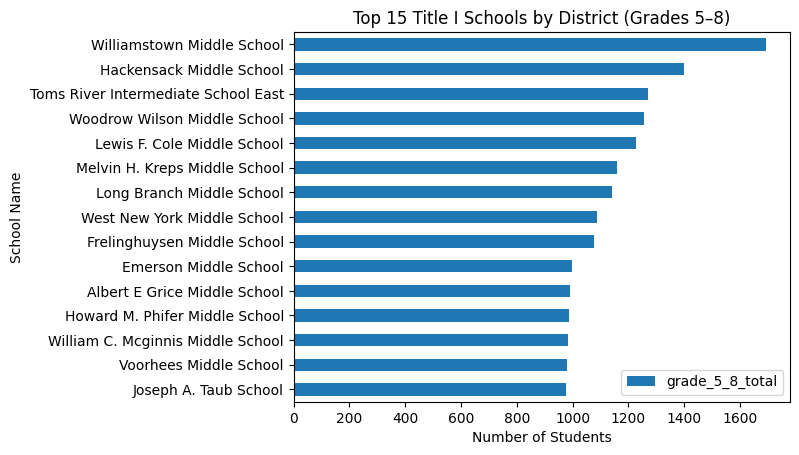

In [41]:
# Create bar chart for top 15 schools based on district rankings
school_rank[school_rank["rank"] == 1.0].sort_values(by="grade_5_8_total", ascending=False).head(15).plot(
    kind="barh",
    x="School Name_enroll",
    y="grade_5_8_total"
)

plt.title("Top 15 Title I Schools by District (Grades 5–8)")
plt.xlabel("Number of Students")
plt.ylabel("School Name")
plt.gca().invert_yaxis()
plt.show()

In [42]:
# List of top 15 schools by district rank
school_rank[school_rank["rank"] == 1.0].sort_values(by="grade_5_8_total", ascending=False).head(15)

,district_key,School Name_enroll,grade_5_8_total,rank
696,MONROE TOWNSHIP,Williamstown Middle School,1694.0,1.0
395,HACKENSACK,Hackensack Middle School,1399.0,1.0
1146,TOMS RIVER,Toms River Intermediate School East,1271.0,1.0
206,CLIFTON,Woodrow Wilson Middle School,1255.0,1.0
321,FORT LEE,Lewis F. Cole Middle School,1227.0,1.0
272,EAST WINDSOR,Melvin H. Kreps Middle School,1160.0,1.0
615,LONG BRANCH,Long Branch Middle School,1142.0,1.0
1257,WEST NEW YORK,West New York Middle School,1087.0,1.0
713,MORRIS,Frelinghuysen Middle School,1078.0,1.0
1181,UNION CITY,Emerson Middle School,999.0,1.0
